# Домашнее задание 4

Анализ и заполнение пропусков в датасете заявок на кредит (`loan_prediction_dataset.csv`).

Для визуализации пропусков использую библиотеку `missingno`, для остальных графиков — `matplotlib` и `seaborn`.

In [1]:
import matplotlib.pyplot as plt
import missingno as msno
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## Задание 1. Чтение датасета (1 балл)

In [2]:
df = pd.read_csv("loan_prediction_dataset.csv")
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Задание 2. Основная информация о датасете (2 балла)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.describe(exclude="number")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


**Вывод:**

- В датасете 614 заявок и 13 признаков: 5 числовых и 8 текстовых. `Loan_ID` — идентификатор заявки, `Loan_Status` — итог (одобрен кредит или нет).
- По `info()` видно, что у части столбцов число непустых значений меньше 614, то есть в них есть пропуски.
- `Credit_History` хранится как число, но принимает только значения 0 и 1, то есть по смыслу это категориальный признак (есть кредитная история или нет).
- `Dependents` хранится как строка из-за значения `3+`.
- Доходы и сумма кредита сильно скошены вправо: среднее заметно больше медианы (например, `ApplicantIncome`: 5403 против 3812), а максимумы на порядок выше третьего квартиля.
- `Loan_Amount_Term` почти всегда равен 360 (все квартили равны 360).

## Задание 3. Таблица пропусков (3 балла)

Считаю для каждого столбца абсолютное число пропусков и их процент от числа строк, сортирую по убыванию.

In [6]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)

missing

,missing_count,missing_percent
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49
Education,0,0.00
Loan_ID,0,0.00
CoapplicantIncome,0,0.00


In [7]:
rows_with_missing = df.isna().any(axis=1).sum()
print(f"Строк хотя бы с одним пропуском: {rows_with_missing} ({rows_with_missing / len(df):.1%})")
print("Распределение числа пропусков в строке:")
print(df.isna().sum(axis=1).value_counts().sort_index())

Строк хотя бы с одним пропуском: 134 (21.8%)
Распределение числа пропусков в строке:
0    480
1    121
2     11
3      2
Name: count, dtype: int64


**Вывод:** пропуски есть в 7 столбцах. Больше всего их в `Credit_History` (50, 8.14 %) и `Self_Employed` (32, 5.21 %), меньше всего в `Married` (3, 0.49 %). Ни в одном столбце пропусков не больше 10 %.

При этом хотя бы один пропуск есть в 134 строках (21.8 %). Если просто удалить такие строки, потеряется больше пятой части данных, поэтому пропуски лучше заполнить.

## Задание 4. Визуализация пропусков (3 балла)

### Матрица пропусков

Каждая строка датасета — горизонтальная линия, белым отмечены пропуски. Справа показано, сколько заполненных значений в строке.

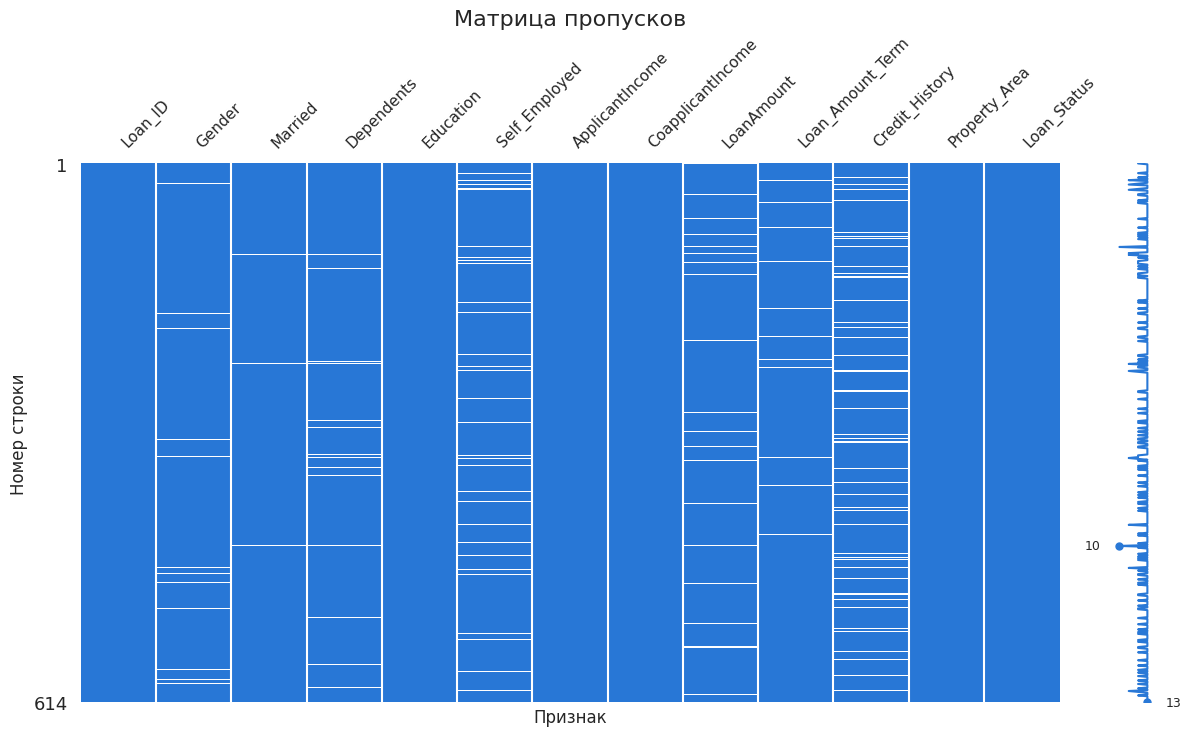

In [8]:
ax = msno.matrix(df, figsize=(14, 7), fontsize=11, color=(0.16, 0.47, 0.84))
ax.set_title("Матрица пропусков", fontsize=16)
ax.set_xlabel("Признак")
ax.set_ylabel("Номер строки")
plt.show()

### Тепловая карта пропусков

Сначала строю тепловую карту по таблице `df.isna()`: по горизонтали признаки, по вертикали строки, цвет показывает, заполнено значение или пропущено.

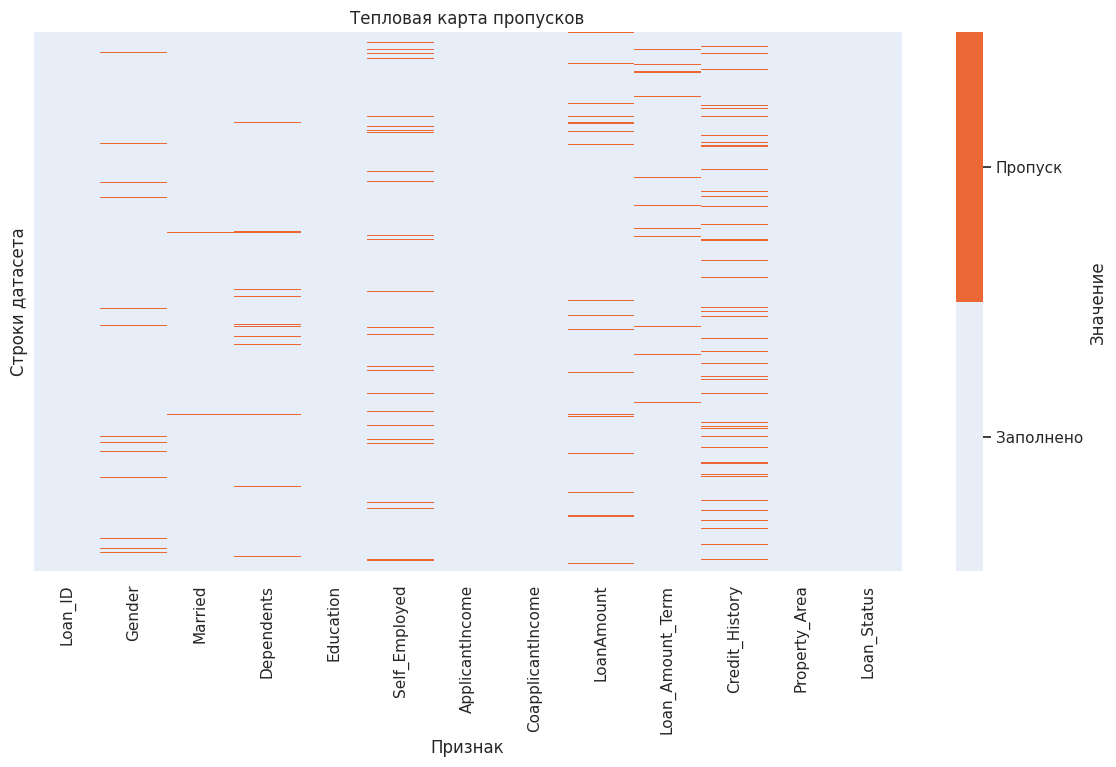

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(df.isna(), cmap=["#e8eef7", "#eb6834"], cbar=True, yticklabels=False, ax=ax,
            cbar_kws={"ticks": [0.25, 0.75]})
colorbar = ax.collections[0].colorbar
colorbar.set_ticklabels(["Заполнено", "Пропуск"])
colorbar.set_label("Значение")
ax.set(title="Тепловая карта пропусков", xlabel="Признак", ylabel="Строки датасета")
plt.show()

Затем строю тепловую карту корреляции пропусков (`msno.heatmap`). Она показывает, насколько часто пропуски в двух столбцах встречаются в одних и тех же строках: 1 — всегда вместе, 0 — независимо, −1 — никогда вместе. На графике только столбцы, в которых есть пропуски.

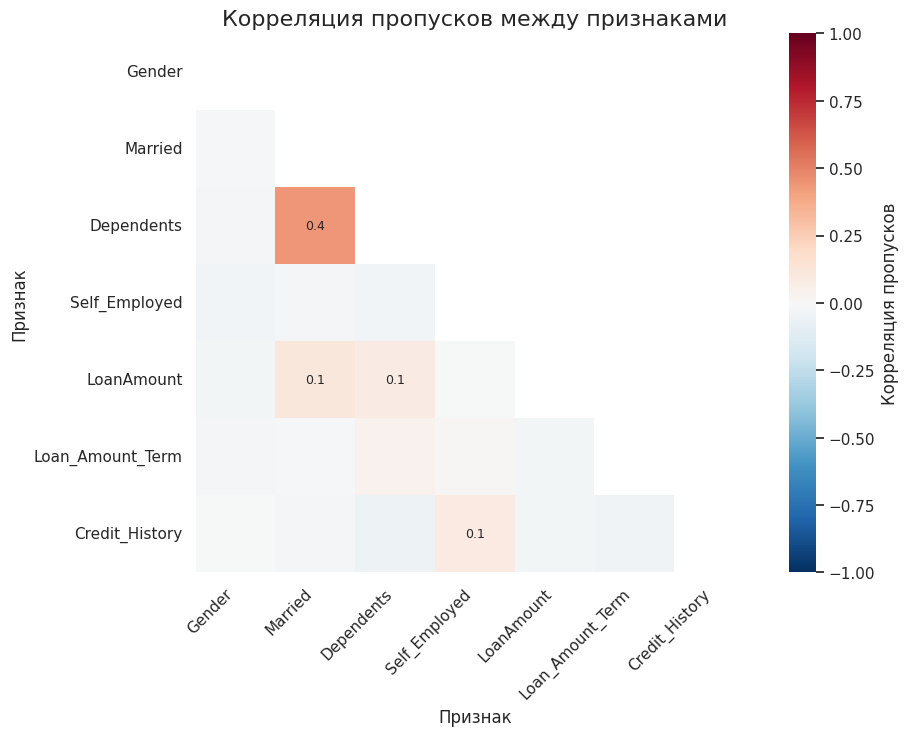

In [10]:
with sns.axes_style("white"):
    ax = msno.heatmap(df, figsize=(9, 7), fontsize=11, cmap="RdBu_r")
ax.set_title("Корреляция пропусков между признаками", fontsize=16)
ax.set_xlabel("Признак")
ax.set_ylabel("Признак")
ax.collections[0].colorbar.set_label("Корреляция пропусков")
plt.show()

`msno.heatmap` округляет значения до одного знака и не подписывает связи слабее 0.1, поэтому считаю ту же матрицу точно. Заодно смотрю на строки, где пропущено семейное положение.

In [11]:
cols_with_missing = df.columns[df.isna().any()].tolist()
df[cols_with_missing].isna().corr().round(2)

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
Gender,1.00,-0.01,-0.02,-0.03,-0.03,-0.02,-0.00
Married,-0.01,1.00,0.44,-0.02,0.11,-0.01,-0.02
Dependents,-0.02,0.44,1.00,-0.04,0.08,0.05,-0.05
Self_Employed,-0.03,-0.02,-0.04,1.00,-0.01,0.01,0.09
LoanAmount,-0.03,0.11,0.08,-0.01,1.00,-0.03,-0.03
Loan_Amount_Term,-0.02,-0.01,0.05,0.01,-0.03,1.00,-0.05
Credit_History,-0.00,-0.02,-0.05,0.09,-0.03,-0.05,1.00


In [12]:
df.loc[df["Married"].isna(), ["Loan_ID", "Married", "Dependents"]]

,Loan_ID,Married,Dependents
104,LP001357,NaN,NaN
228,LP001760,NaN,NaN
435,LP002393,NaN,NaN


## Задание 5. Интерпретация графиков (2 балла)

- **Матрица пропусков.** Белые полосы разбросаны по всей высоте матрицы без явных сгустков: пропуски не собраны в отдельной части датасета (например, в начале или в конце файла). Сильнее всего «пестрят» столбцы `Credit_History` и `Self_Employed`, что совпадает с таблицей пропусков. По линии справа видно, что в строке пропущено не больше 3 значений из 13, то есть «пустых» заявок нет.
- **Тепловая карта `df.isna()`.** Подтверждает то же самое: оранжевые отметки редкие и рассеяны по строкам, полностью пустых столбцов и строк нет. Столбцы `Loan_ID`, `Education`, доходы, `Property_Area` и `Loan_Status` заполнены полностью.
- **Корреляция пропусков.** Почти все значения близки к нулю: пропуск в одном признаке практически не связан с пропуском в другом. Выделяется пара `Married` и `Dependents` (0.44, на графике округлено до 0.4): во всех трёх заявках без семейного положения не указано и число иждивенцев. Это логично: оба поля относятся к одному блоку анкеты о семье. Остальные связи слабые (не больше 0.1 по модулю, например `Self_Employed` и `Credit_History`), и на заполнение они не влияют.

**Итог:** пропуски выглядят случайными, их мало в каждом столбце, поэтому их можно заполнить простыми статистиками, не опасаясь сильно исказить данные.

## Задание 6. Разделение признаков с пропусками на числовые и категориальные (2 балла)

Делю по смыслу признака, а не только по типу данных:

- `Credit_History` хранится как `float`, но у него всего два значения (0 и 1), это категория «есть / нет кредитной истории»;
- `Dependents` хранится как строка из-за значения `3+`, это категория;
- `LoanAmount` и `Loan_Amount_Term` — настоящие числовые признаки.

Для проверки вывожу тип данных и число уникальных значений каждого столбца с пропусками (список `cols_with_missing` получен выше, в задании 4).

In [13]:
pd.DataFrame({
    "dtype": df[cols_with_missing].dtypes.astype(str),
    "unique_values": df[cols_with_missing].nunique(),
    "missing_count": df[cols_with_missing].isna().sum(),
})

,dtype,unique_values,missing_count
Gender,str,2,13
Married,str,2,3
Dependents,str,4,15
Self_Employed,str,2,32
LoanAmount,float64,203,22
Loan_Amount_Term,float64,10,14
Credit_History,float64,2,50


In [14]:
numeric_missing = ["LoanAmount", "Loan_Amount_Term"]
categorical_missing = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]

assert sorted(numeric_missing + categorical_missing) == sorted(cols_with_missing)

print("Числовые:", numeric_missing)
print("Категориальные:", categorical_missing)

Числовые: ['LoanAmount', 'Loan_Amount_Term']
Категориальные: ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']


## Задание 7. Заполнение пропусков (4 балла)

Перед заполнением смотрю на распределения числовых признаков, чтобы выбрать метод.

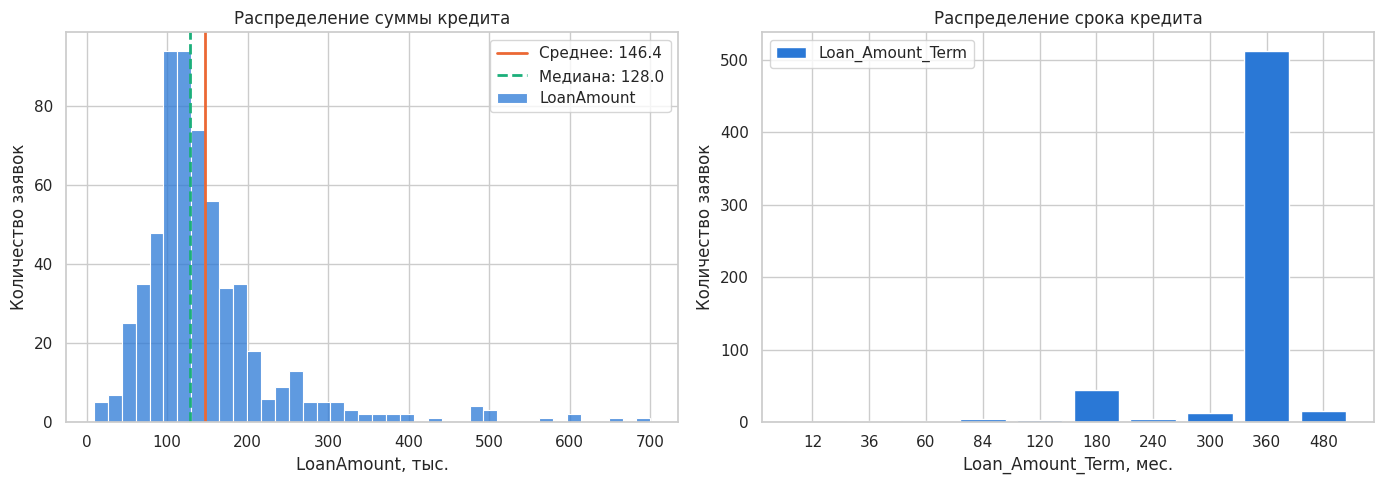

Асимметрия LoanAmount: 2.68
Доля срока 360 мес.: 83.4%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["LoanAmount"], bins=40, color="#2a78d6", label="LoanAmount", ax=axes[0])
axes[0].axvline(df["LoanAmount"].mean(), color="#eb6834", linewidth=2,
                label=f"Среднее: {df['LoanAmount'].mean():.1f}")
axes[0].axvline(df["LoanAmount"].median(), color="#1baf7a", linewidth=2, linestyle="--",
                label=f"Медиана: {df['LoanAmount'].median():.1f}")
axes[0].set(title="Распределение суммы кредита", xlabel="LoanAmount, тыс.", ylabel="Количество заявок")
axes[0].legend()

term_counts = df["Loan_Amount_Term"].value_counts().sort_index()
axes[1].bar(term_counts.index.astype(int).astype(str), term_counts.values, color="#2a78d6", label="Loan_Amount_Term")
axes[1].set(title="Распределение срока кредита", xlabel="Loan_Amount_Term, мес.", ylabel="Количество заявок")
axes[1].legend()

fig.tight_layout()
plt.show()

print("Асимметрия LoanAmount:", round(df["LoanAmount"].skew(), 2))
print("Доля срока 360 мес.:", f"{(df['Loan_Amount_Term'] == 360).mean():.1%}")

**Выбор методов:**

| Признак | Тип | Метод | Обоснование |
|---|---|---|---|
| `LoanAmount` | числовой, непрерывный | медиана | Распределение сильно скошено вправо (асимметрия ≈ 2.7), есть крупные выбросы до 700. Среднее смещено выбросами, а медиана к ним устойчива. |
| `Loan_Amount_Term` | числовой, дискретный | мода | Срок принимает только стандартные значения (12, 36, …, 480), и 360 месяцев встречается в 83 % заявок. Среднее (342) — несуществующий срок, а мода даёт реальное и самое типичное значение. |
| `Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History` | категориальные | мода | Среднее и медиана для категорий не имеют смысла. Пропусков мало (до 8 %), и в каждом признаке есть явно преобладающее значение, поэтому заполнение самым частым значением почти не меняет распределение. |

Заполняю копию датасета, чтобы исходный `df` остался для сравнения. Значения для заполнения вычисляются по данным, а не вписываются вручную.

In [16]:
df_filled = df.copy()

fill_values = {}

fill_values["LoanAmount"] = df["LoanAmount"].median()
fill_values["Loan_Amount_Term"] = df["Loan_Amount_Term"].mode()[0]

for col in categorical_missing:
    fill_values[col] = df[col].mode()[0]

df_filled = df_filled.fillna(value=fill_values)

pd.Series(fill_values, name="fill_value").to_frame()

,fill_value
LoanAmount,128.0
Loan_Amount_Term,360.0
Gender,Male
Married,Yes
Dependents,0
Self_Employed,No
Credit_History,1.0


## Задание 8. Проверка заполнения (1 балл)

Проверяю, что:

1. пропусков больше нет;
2. размер таблицы не изменился;
3. типы данных остались прежними;
4. известные значения не изменились — отличаться могут только те ячейки, где раньше был пропуск;
5. в каждой ячейке, где был пропуск, стоит выбранное значение.

In [17]:
print("Пропусков после заполнения:", df_filled.isna().sum().sum())
print("Размер до и после:", df.shape, df_filled.shape)
print("Типы данных совпадают:", (df.dtypes == df_filled.dtypes).all())

known = df.notna()
print("Известные значения не изменились:", df_filled[known].equals(df[known]))

for col, value in fill_values.items():
    filled_cells = df_filled.loc[df[col].isna(), col]
    assert (filled_cells == value).all(), col
print("Все пропуски заполнены выбранными значениями")

Пропусков после заполнения: 0
Размер до и после: (614, 13) (614, 13)
Типы данных совпадают: True
Известные значения не изменились: True
Все пропуски заполнены выбранными значениями


In [18]:
df_filled.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

**Вывод:** все проверки пройдены: пропусков не осталось, размер и типы данных не изменились, а заменены только пустые ячейки.

## Задание 9. Статистики до и после заполнения (2 балла)

### Числовые признаки

In [19]:
stats_before = df[numeric_missing].agg(["count", "mean", "median", "std", "min", "max"])
stats_after = df_filled[numeric_missing].agg(["count", "mean", "median", "std", "min", "max"])

numeric_comparison = pd.concat({"до": stats_before, "после": stats_after}, axis=1)
numeric_comparison = numeric_comparison.swaplevel(axis=1).sort_index(axis=1, level=0)
numeric_comparison.round(2)

LoanAmount         Loan_Amount_Term        
               до   после               до   после
count      592.00  614.00           600.00  614.00
mean       146.41  145.75           342.00  342.41
median     128.00  128.00           360.00  360.00
std         85.59   84.11            65.12   64.43
min          9.00    9.00            12.00   12.00
max        700.00  700.00           480.00  480.00

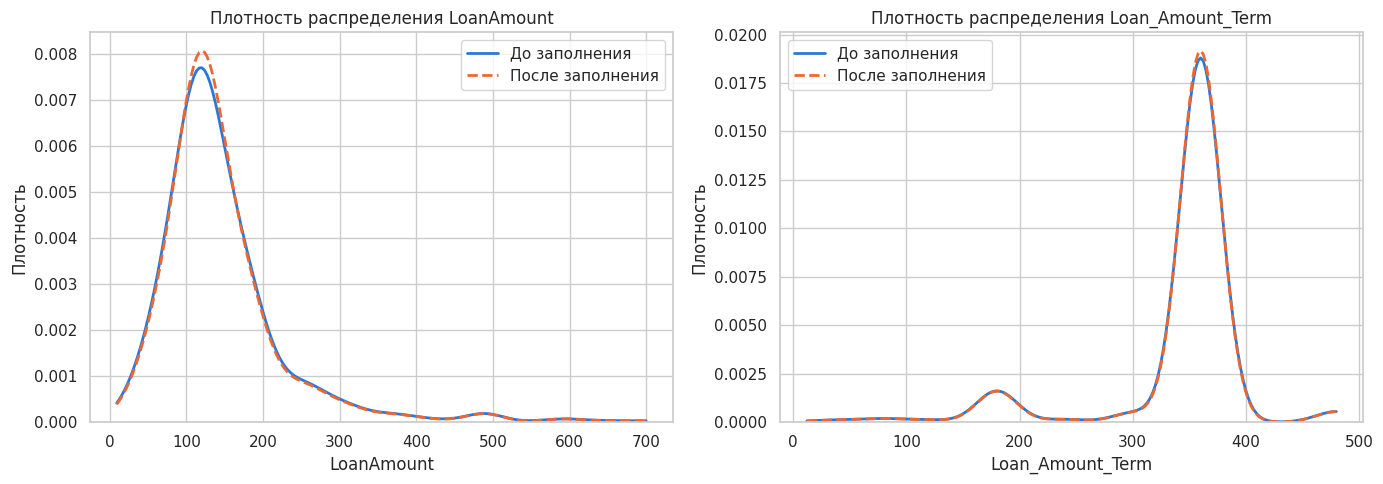

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, numeric_missing):
    sns.kdeplot(df[col].dropna(), ax=ax, color="#2a78d6", linewidth=2, cut=0, label="До заполнения")
    sns.kdeplot(df_filled[col], ax=ax, color="#eb6834", linewidth=2, linestyle="--", cut=0, label="После заполнения")
    ax.set(title=f"Плотность распределения {col}", xlabel=col, ylabel="Плотность")
    ax.legend()

fig.tight_layout()
plt.show()

### Категориальные признаки

Сравниваю доли значений до заполнения (без учёта пропусков) и после.

In [21]:
categorical_comparison = []
for col in categorical_missing:
    before = df[col].value_counts(normalize=True)
    after = df_filled[col].value_counts(normalize=True)
    table = pd.DataFrame({"доля до, %": before * 100, "доля после, %": after * 100})
    table["изменение, п.п."] = table["доля после, %"] - table["доля до, %"]
    table.index = pd.MultiIndex.from_product([[col], table.index.astype(str)], names=["признак", "значение"])
    categorical_comparison.append(table)

pd.concat(categorical_comparison).round(2)

доля до, %  доля после, %  изменение, п.п.
признак        значение                                            
Gender         Male           81.36          81.76             0.39
               Female         18.64          18.24            -0.39
Married        Yes            65.14          65.31             0.17
               No             34.86          34.69            -0.17
Dependents     0              57.60          58.63             1.04
               1              17.03          16.61            -0.42
               2              16.86          16.45            -0.41
               3+              8.51           8.31            -0.21
Self_Employed  No             85.91          86.64             0.73
               Yes            14.09          13.36            -0.73
Credit_History 1.0            84.22          85.50             1.29
               0.0            15.78          14.50            -1.29

**Комментарий:**

- **`LoanAmount`.** Число значений выросло с 592 до 614. Медиана не изменилась (128), среднее немного снизилось (146.4 → 145.8), потому что добавились значения ниже среднего. Стандартное отклонение уменьшилось (85.6 → 84.1): 22 одинаковых значения в центре распределения сужают разброс. На графике плотности кривые почти совпадают, лишь чуть выше пик около медианы.
- **`Loan_Amount_Term`.** Мода и медиана остались равны 360, среднее немного выросло (342.0 → 342.4), разброс уменьшился. Форма распределения практически не изменилась.
- **Категориальные признаки.** Доля самого частого значения выросла, у остальных значений немного уменьшилась. Сильнее всего изменились `Credit_History` (доля значения 1 выросла на 1.3 п. п., у этого признака больше всего пропусков) и `Dependents` (доля значения 0 выросла на 1.0 п. п.). У `Gender`, `Married` и `Self_Employed` изменения меньше 1 п. п.

**Итог:** заполнение почти не исказило распределения: минимум и максимум не изменились, центральные значения сохранились. Побочный эффект простого заполнения — небольшое занижение разброса и небольшой сдвиг в сторону самого частого значения. При такой доле пропусков это приемлемо.